# Examen práctico — Módulo 2
### Materia: Laboratorio de Aprendizaje Estadístico
### Profesor: Antonio Manguart Paez
### Alumna: Maria Fernanda Gómez Flores


Instrucciones
Realiza un modelo de clasificación para predecir la variable respuesta del dataset asignado.

Tu entrega debe incluir:

Una breve exploración de datos, especialmente contra la variable respuesta.

División de datos en entrenamiento y prueba: 80% train / 20% test.

Aplicación de los modelos de clasificación vistos en clase.

Cálculo y comparación del AUC de cada modelo.

Un intento razonable por mejorar el AUC.

Una breve conclusión indicando:

qué modelo funcionó mejor,

qué AUC obtuvo,

qué decisiones ayudaron a mejorar el resultado.

Se evaluará el flujo completo: exploración, preparación, modelado, evaluación e interpretación.



## Preparación de datos

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

In [2]:
df = pd.read_csv('diabetes.csv')
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,diabetes
0,Female,80.0,0,1,never,25.19,0
1,Female,54.0,0,0,No Info,27.32,0
2,Male,28.0,0,0,never,27.32,0
3,Female,36.0,0,0,current,23.45,0
4,Male,76.0,1,1,current,20.14,0


In [3]:
df.isna().mean()

gender             0.0
age                0.0
hypertension       0.0
heart_disease      0.0
smoking_history    0.0
bmi                0.0
diabetes           0.0
dtype: float64

In [4]:
df = df.fillna(df.mean(numeric_only=True))

In [5]:
df.isna().mean()

gender             0.0
age                0.0
hypertension       0.0
heart_disease      0.0
smoking_history    0.0
bmi                0.0
diabetes           0.0
dtype: float64

## Exploración de datos

In [6]:
df.diabetes.mean()

np.float64(0.085)

El target es diabetes donde 1 significa que la persona tiene diabetes y 0 que no tiene

con el promedio puedo ver que proporcion de los datos pertenece a la clase 1 y que tan balanceado esta el target

In [7]:
df.groupby('diabetes').mean(numeric_only=True)

,age,hypertension,heart_disease,bmi
diabetes,,,,
0,40.115187,0.058984,0.029235,26.887163
1,60.946588,0.245647,0.149059,31.988382


Compare los promedios de las variables numericas entre las personas que tienen diabetes y las que no tienen

esto me ayuda a ver que variables cambian mas entre las dos clases y cuales parecen aportar mas informacion para la clasificacion

In [8]:
df.groupby('gender').diabetes.mean()

gender
Female    0.076189
Male      0.097490
Other     0.000000
Name: diabetes, dtype: float64

In [9]:
df.groupby('smoking_history').diabetes.mean()

smoking_history
No Info        0.040596
current        0.102089
ever           0.117882
former         0.170017
never          0.095341
not current    0.107027
Name: diabetes, dtype: float64

Tambien revise las variables categoricas contra diabetes para ver si la proporcion de personas con diabetes cambia dependiendo del genero o del historial de tabaquismo

## Target

In [10]:
y = df['diabetes']

X = df.copy()
del X['diabetes']

gender y smoking_history son categoricas entonces las convierto a dummies

In [11]:
categoricas = [
    'gender',
    'smoking_history'
]

In [12]:
X = pd.get_dummies(X, columns=categoricas)

In [13]:
X.head()

,age,hypertension,heart_disease,bmi,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,True,False,False,False,False,False,False,True,False
1,54.0,0,0,27.32,True,False,False,True,False,False,False,False,False
2,28.0,0,0,27.32,False,True,False,False,False,False,False,True,False
3,36.0,0,0,23.45,True,False,False,False,True,False,False,False,False
4,76.0,1,1,20.14,False,True,False,False,True,False,False,False,False


## Train / Test

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

Dividi los datos en 80% entrenamiento y 20% prueba

use stratify para mantener aproximadamente la misma proporcion de diabetes en los dos grupos

## Regresión Logística

In [15]:
from sklearn.linear_model import LogisticRegression

In [16]:
model_logistica = LogisticRegression(max_iter=2000)
model_logistica.fit(X_train,y_train)

LogisticRegression(max_iter=2000)

In [17]:
probabilidades_logistica = model_logistica.predict_proba(X_test)[:,1]
probabilidades_logistica

array([0.01999936, 0.02301267, 0.05576908, ..., 0.02963295, 0.10590034,
       0.123958  ])

In [18]:
from sklearn.metrics import roc_auc_score

auc_logistica = roc_auc_score(y_score=probabilidades_logistica, y_true=y_test)
auc_logistica

np.float64(0.8379282545805208)

In [19]:
from sklearn.metrics import roc_curve

fpr_logistica, tpr_logistica, umbrales = roc_curve(
    y_true=y_test,
    y_score=probabilidades_logistica
)

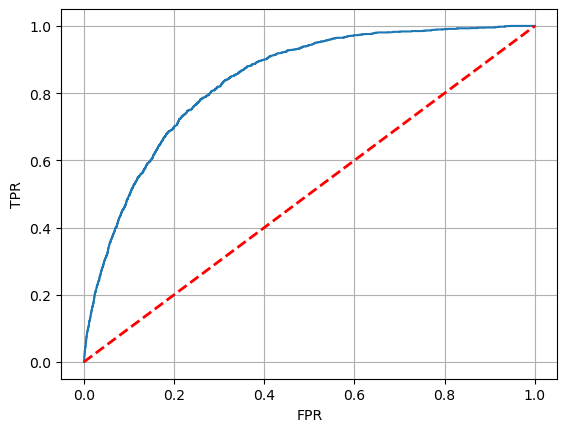

In [20]:
plt.plot(fpr_logistica,tpr_logistica)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Clasificador aleatorio')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.grid()

La regresion logistica me sirve como primer modelo para comparar

el AUC indica que tan bien logra separar a las personas con diabetes de las que no tienen y entre mas cerca este de 1 mejor separa las dos clases

## KNN

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [22]:
model_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

model_knn.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier())])

In [23]:
probabilidades_knn = model_knn.predict_proba(X_test)[:,1]
probabilidades_knn

array([0., 0., 0., ..., 0., 0., 0.])

In [24]:
auc_knn = roc_auc_score(y_score=probabilidades_knn, y_true=y_test)
auc_knn

np.float64(0.7035451783992286)

In [25]:
fpr_knn, tpr_knn, umbrales = roc_curve(
    y_true=y_test,
    y_score=probabilidades_knn
)

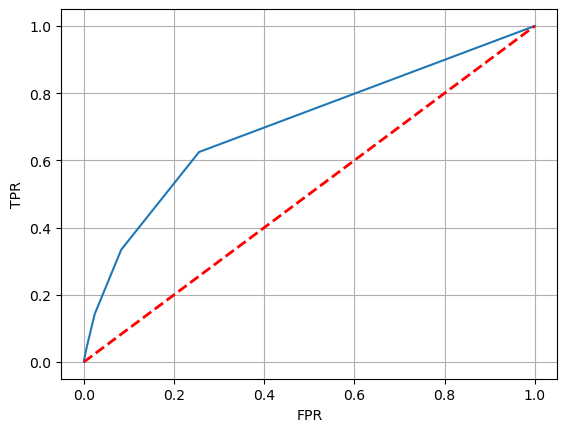

In [26]:
plt.plot(fpr_knn,tpr_knn)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Clasificador aleatorio')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.grid()

En KNN use StandardScaler porque el modelo trabaja con distancias y asi ninguna variable pesa mas solamente por tener valores mas grandes

primero use 5 vecinos para tener un modelo base y poder comparar su AUC

## Polinomial

In [27]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [28]:
pipeline = Pipeline([
    ('poly', PolynomialFeatures()),
    ('scaler', StandardScaler()),
    ('model', linear_model.LogisticRegression())
])

In [29]:
params = {
    'poly__degree': [1,2]
}

In [30]:
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=params,
    scoring='roc_auc',
    cv=5
)

In [31]:
grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('poly', PolynomialFeatures()),
                                       ('scaler', StandardScaler()),
                                       ('model', LogisticRegression())]),
             param_grid={'poly__degree': [1, 2]}, scoring='roc_auc')

In [32]:
grid.best_params_

{'poly__degree': 2}

In [33]:
probabilidades_poly = grid.predict_proba(X_test)[:,1]
probabilidades_poly

array([0.01581558, 0.01676509, 0.05236958, ..., 0.02522618, 0.08552532,
       0.11908221])

In [34]:
auc_poly = roc_auc_score(y_score=probabilidades_poly, y_true=y_test)
auc_poly

np.float64(0.8402026036644167)

In [35]:
fpr_poly, tpr_poly, umbrales = roc_curve(
    y_true=y_test,
    y_score=probabilidades_poly
)

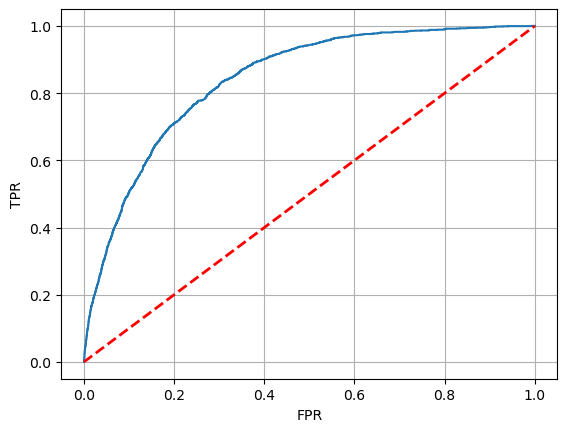

In [36]:
plt.plot(fpr_poly,tpr_poly)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Clasificador aleatorio')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.grid()

En el modelo polinomial use cross validation para comparar grados 1 y 2 y seleccionar el que obtenga mejor AUC

esto permite revisar si agregar relaciones de mayor grado entre las variables mejora la separacion de las dos clases

## Ridge

In [37]:
model_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', linear_model.LogisticRegression(penalty='l2'))
])

model_ridge.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LogisticRegression())])

In [38]:
probabilidades_ridge = model_ridge.predict_proba(X_test)[:,1]
probabilidades_ridge

array([0.01988978, 0.02293254, 0.05598907, ..., 0.02953891, 0.10577688,
       0.12403573])

In [39]:
auc_ridge = roc_auc_score(y_score=probabilidades_ridge, y_true=y_test)
auc_ridge

np.float64(0.8379898746383799)

In [40]:
fpr_ridge, tpr_ridge, umbrales = roc_curve(
    y_true=y_test,
    y_score=probabilidades_ridge
)

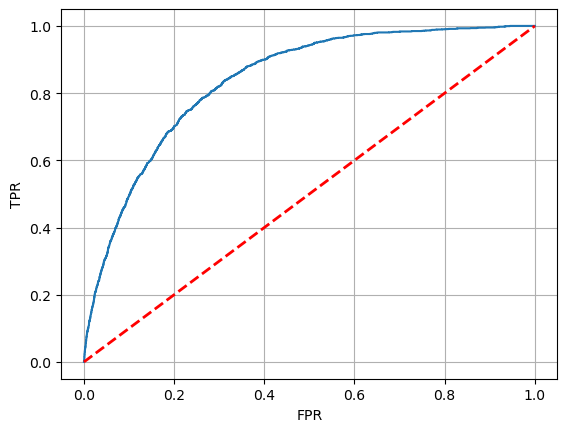

In [41]:
plt.plot(fpr_ridge,tpr_ridge)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Clasificador aleatorio')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.grid()

Ridge usa penalizacion L2 para controlar los coeficientes del modelo

calcule su AUC sobre los mismos datos de prueba para poder compararlo de forma justa con los demas modelos

## LDA

In [42]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [43]:
pipeline_lda = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis())
])

pipeline_lda.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lda', LinearDiscriminantAnalysis())])

In [44]:
probabilidades_lda = pipeline_lda.predict_proba(X_test)[:,1]

In [45]:
auc_lda = roc_auc_score(y_score=probabilidades_lda, y_true=y_test)
auc_lda

np.float64(0.8307843137254902)

In [46]:
fpr_lda, tpr_lda, umbrales = roc_curve(
    y_true=y_test,
    y_score=probabilidades_lda
)

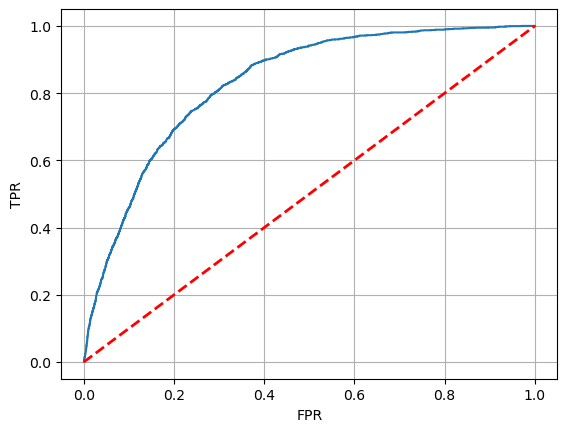

In [47]:
plt.plot(fpr_lda,tpr_lda)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Clasificador aleatorio')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.grid()

LDA busca una combinacion de las variables que permita separar las dos clases

tambien lo evalue con AUC sobre el mismo conjunto de prueba

## Red neuronal

In [48]:
from sklearn.neural_network import MLPClassifier

In [49]:
pipeline_red = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        max_iter=500000,
        early_stopping=True,
        n_iter_no_change=20,
        random_state=42
    ))
])

param_grid = {
    'mlp__hidden_layer_sizes': [(10,), (20,), (20,10)],
    'mlp__alpha': [0.001, 0.1],
    'mlp__activation': ['relu', 'tanh'],
}

grid_red = GridSearchCV(
    pipeline_red,
    param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1
)

grid_red.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('mlp',
                                        MLPClassifier(early_stopping=True,
                                                      max_iter=500000,
                                                      n_iter_no_change=20,
                                                      random_state=42))]),
             n_jobs=-1,
             param_grid={'mlp__activation': ['relu', 'tanh'],
                         'mlp__alpha': [0.001, 0.1],
                         'mlp__hidden_layer_sizes': [(10,), (20,), (20, 10)]},
             scoring='roc_auc')

In [50]:
grid_red.best_params_

{'mlp__activation': 'relu',
 'mlp__alpha': 0.1,
 'mlp__hidden_layer_sizes': (20, 10)}

In [51]:
probabilidades_red = grid_red.best_estimator_.predict_proba(X_test)[:, 1]

auc_red = roc_auc_score(y_test, probabilidades_red)
auc_red

np.float64(0.8395613629058181)

In [52]:
fpr_red, tpr_red, umbrales = roc_curve(
    y_true=y_test,
    y_score=probabilidades_red
)

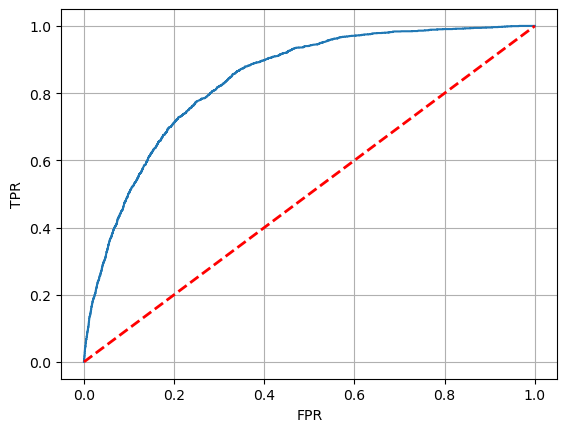

In [53]:
plt.plot(fpr_red,tpr_red)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Clasificador aleatorio')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.grid()

En la red neuronal use StandardScaler y GridSearchCV para probar diferentes capas ocultas alpha y funciones de activacion

el objetivo es seleccionar la configuracion que tenga mejor AUC en cross validation y despues evaluarla en test

## Comparación de modelos

In [54]:
resultados = pd.DataFrame({
    'Modelo': [
        'Regresión Logística',
        'KNN',
        'Polinomial',
        'Ridge',
        'LDA',
        'Red neuronal'
    ],
    'AUC': [
        auc_logistica,
        auc_knn,
        auc_poly,
        auc_ridge,
        auc_lda,
        auc_red
    ]
})

resultados = resultados.sort_values(by='AUC',ascending=False)
resultados

,Modelo,AUC
2,Polinomial,0.840203
5,Red neuronal,0.839561
3,Ridge,0.837990
0,Regresión Logística,0.837928
4,LDA,0.830784
1,KNN,0.703545


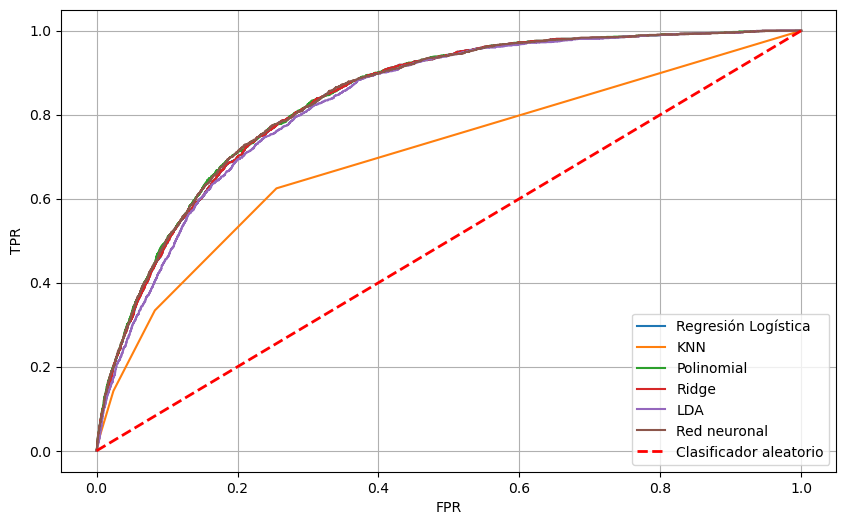

In [55]:
plt.figure(figsize=(10,6))

plt.plot(fpr_logistica,tpr_logistica,label="Regresión Logística")
plt.plot(fpr_knn,tpr_knn,label="KNN")
plt.plot(fpr_poly,tpr_poly,label="Polinomial")
plt.plot(fpr_ridge,tpr_ridge,label="Ridge")
plt.plot(fpr_lda,tpr_lda,label="LDA")
plt.plot(fpr_red,tpr_red,label="Red neuronal")

plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Clasificador aleatorio')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid()

Compare todos los modelos usando AUC y los mismos datos de prueba

el modelo que quede primero en la tabla es el que mejor logra separar a las personas con diabetes de las que no tienen

## Intento por mejorar el AUC

Para intentar mejorar el AUC voy a ajustar KNN

en lugar de quedarme con 5 vecinos voy a probar diferentes valores de k con cross validation y voy a elegir el que tenga mejor AUC

In [56]:
modelo_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

In [57]:
params = {
    'model__n_neighbors': range(1, 51)
}

In [58]:
grid_knn = GridSearchCV(
    modelo_knn,
    params,
    cv=5,
    scoring='roc_auc'
)

grid_knn.fit(X_train, y_train)

Exception ignored in: <function ResourceTracker.__del__ at 0x10408dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105fd9bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1026f9bc0>
Traceback (most recent call last

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', KNeighborsClassifier())]),
             param_grid={'model__n_neighbors': range(1, 51)},
             scoring='roc_auc')

In [59]:
grid_knn.best_params_

{'model__n_neighbors': 50}

In [60]:
probabilidades_knn_mejorado = grid_knn.predict_proba(X_test)[:,1]

auc_knn_mejorado = roc_auc_score(
    y_score=probabilidades_knn_mejorado,
    y_true=y_test
)

auc_knn_mejorado

np.float64(0.8216004660880747)

Compare el AUC de KNN con 5 vecinos contra el AUC del KNN ajustado con cross validation

si el segundo AUC es mayor entonces elegir k con validacion cruzada si ayudo a mejorar el resultado

## Comparación final

In [61]:
resultados_finales = pd.DataFrame({
    'Modelo': [
        'Regresión Logística',
        'KNN',
        'KNN mejorado',
        'Polinomial',
        'Ridge',
        'LDA',
        'Red neuronal'
    ],
    'AUC': [
        auc_logistica,
        auc_knn,
        auc_knn_mejorado,
        auc_poly,
        auc_ridge,
        auc_lda,
        auc_red
    ]
})

resultados_finales = resultados_finales.sort_values(by='AUC',ascending=False)
resultados_finales

,Modelo,AUC
3,Polinomial,0.840203
6,Red neuronal,0.839561
4,Ridge,0.837990
0,Regresión Logística,0.837928
5,LDA,0.830784
2,KNN mejorado,0.821600
1,KNN,0.703545


## Calibración del mejor modelo

Despues de comparar los AUC reviso la calibracion del modelo que haya quedado con el mejor resultado

en probabilidades_mejor se debe usar la variable de probabilidades del modelo ganador

In [62]:
# Cambiar por las probabilidades del modelo que haya obtenido el mayor AUC
probabilidades_mejor = probabilidades_poly

In [63]:
df_calibracion = pd.DataFrame({
    'y': y_test,
    'probabilidad': probabilidades_mejor
})

In [64]:
df_calibracion['probabilidad_bin'] = pd.qcut(
    df_calibracion['probabilidad'],
    q=10,
    labels=False
) + 1

In [65]:
calibracion = df_calibracion.groupby('probabilidad_bin').mean()
calibracion

,y,probabilidad
probabilidad_bin,,
1,0.003974,0.001373
2,0.006039,0.004539
3,0.006500,0.010467
4,0.012994,0.019741
5,0.030015,0.033133
6,0.048500,0.051737
7,0.081000,0.076957
8,0.112500,0.115540
9,0.200000,0.184703


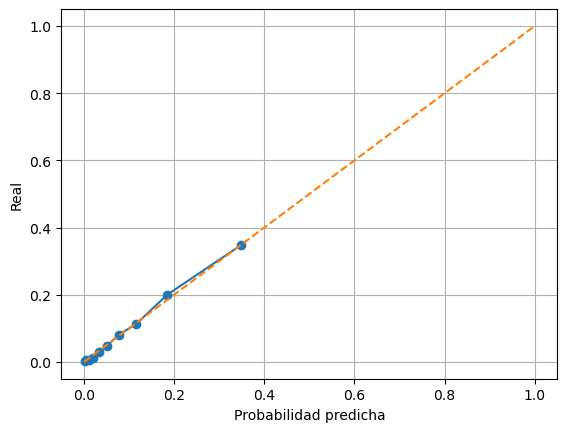

In [66]:
plt.plot(calibracion.probabilidad, calibracion.y, marker="o")
plt.plot([0,1],[0,1],"--")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Real")
plt.grid()

La calibracion compara la probabilidad que predice el modelo contra lo que realmente paso

si los puntos quedan cerca de la diagonal significa que las probabilidades del modelo estan bien calibradas

## Conclusión

Se compararon los modelos de clasificacion usando AUC porque permite medir que tan bien separan las dos clases

primero revise los datos y la variable diabetes y despues converti las variables categoricas a dummies
los datos se dividieron en 80% entrenamiento y 20% prueba manteniendo la proporcion del target con stratify

se probaron regresion logistica KNN polinomial Ridge LDA y red neuronal usando los mismos datos de prueba

tambien se hizo un intento por mejorar KNN probando diferentes valores de k con cross validation en lugar de usar solamente 5 vecinos

el modelo que quede primero en resultados_finales es el que obtuvo el mayor AUC y por lo tanto fue el que mejor funciono para separar las personas con diabetes de las que no tienen

despues se revisa la calibracion del mejor modelo para comparar sus probabilidades predichas contra lo que realmente paso